### Dipole moment prediction with ML

In HBQ, which undergoes excited-state intramolecular proton transfer (ESIPT), the transition dipole moment (TDM) is crucial because it determines how strongly the molecule interacts with light. The TDM controls the intensity of absorption and emission, meaning it directly affects fluorescence efficiency. During proton transfer, the molecular geometry and electronic distribution change significantly between the enol and keto forms, leading to variations in the transition dipole moment. By predicting the TDM from molecular geometries, we can understand how structural changes along the proton transfer coordinate influence the optical properties of HBQ. This is essential for accurately modeling its photodynamics and fluorescence.

In [77]:
import numpy as np
import pandas as pd

from copy import deepcopy

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score

# Linear Models
from sklearn.linear_model import LinearRegression, Ridge

# Tree-Based Models
from sklearn.ensemble import RandomForestRegressor

# Neural network models
from sklearn.neural_network import MLPRegressor

# Gradient Boosting Models
from xgboost import XGBRegressor

import seaborn as sns
import matplotlib.pyplot as plt

In [39]:
def create_train_subsets(X, y, percentages, shuffle=True, random_state=None):

    X = np.array(X)
    y = np.array(y)

    n = len(X)
    if shuffle:
        rng = np.random.default_rng(random_state)
        indices = rng.permutation(n)
        X = X[indices]
        y = y[indices]

    subsets = []
    for p in percentages:
        if not 0 < p <= 1:
            raise ValueError("Percentages must be between 0 and 1")

        k = int(p * n)
        subsets.append((X[:k], y[:k]))

    return subsets

### 1. Load data

In [57]:
data = pd.read_csv("trajs-dataframe-pc.csv")
data

,TRAJ,Time,x1,y1,z1,x2,y2,z2,x3,y3,...,z23,x24,y24,z24,mu_x,mu_y,mu_z,mu_x_pc,mu_y_pc,mu_z_pc
0,1,0.5,-0.903948,2.567011,0.066012,1.375391,1.360069,-0.122150,0.848979,0.165433,...,0.206331,-4.208275,-0.299556,-0.045503,-1.298255,0.060673,-0.002043,-1.298255,0.060673,-0.002043
1,1,1.0,-0.903835,2.562395,0.065014,1.380791,1.361061,-0.124760,0.841877,0.155487,...,0.193118,-4.222286,-0.319823,-0.051924,1.330744,-0.063285,0.004413,-1.330744,0.063285,-0.004413
2,1,1.5,-0.903613,2.557535,0.064056,1.385793,1.362369,-0.127433,0.834433,0.145367,...,0.180662,-4.265446,-0.344548,-0.060105,-1.377839,0.065160,-0.006069,-1.377839,0.065160,-0.006069
3,1,2.0,-0.903245,2.552448,0.063149,1.390274,1.363923,-0.130158,0.826782,0.135235,...,0.169053,-4.328030,-0.371130,-0.069135,1.431230,-0.067969,0.006861,-1.431230,0.067969,-0.006861
4,1,2.5,-0.902709,2.547157,0.062301,1.394119,1.365663,-0.132925,0.819068,0.125243,...,0.158393,-4.399876,-0.396572,-0.077975,1.484248,-0.072878,0.006718,-1.484248,0.072878,-0.006718
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42995,215,98.0,-0.934367,2.541373,0.038740,1.475924,1.438822,0.065239,0.778559,0.125982,...,0.018664,-4.513288,-0.037115,-0.031534,-1.884159,0.072271,-0.012103,-1.884159,0.072271,-0.012103
42996,215,98.5,-0.930888,2.543931,0.038357,1.476764,1.435126,0.065179,0.778242,0.132994,...,0.006837,-4.498413,-0.056363,-0.037674,1.861778,-0.057815,0.010398,-1.861778,0.057815,-0.010398
42997,215,99.0,-0.927550,2.546153,0.037961,1.477164,1.430590,0.064979,0.778772,0.140455,...,-0.004734,-4.487472,-0.077722,-0.043962,-1.829654,0.037963,-0.008759,-1.829654,0.037963,-0.008759
42998,215,99.5,-0.924355,2.548018,0.037551,1.477064,1.425246,0.064641,0.780161,0.148247,...,-0.015892,-4.482751,-0.100842,-0.050284,1.787543,-0.012123,0.007323,-1.787543,0.012123,-0.007323


In [58]:
# concatenated ccordinates
coords = data.drop(columns=["TRAJ", "Time", "mu_x", "mu_y", "mu_z", "mu_x_pc", "mu_y_pc", "mu_z_pc"])
coords = coords.values

# transition dipole components
# mu_x, mu_y, mu_z = data["mu_x"], data["mu_y"], data["mu_z"]
mu_x, mu_y, mu_z = data["mu_x_pc"], data["mu_y_pc"], data["mu_z_pc"]

# choose just one component for tests
dipole = mu_z.values

### 2. Split data

In [65]:
# train/test split
coords_train, coords_test, dipole_train, dipole_test = train_test_split(coords, dipole, test_size=0.2, random_state=42)

# train size options
percentages = [0.1, 0.2, 0.5, 0.7, 1.0]
subsets = create_train_subsets(coords_train, dipole_train, percentages, random_state=42)

### 3. Build model

In [66]:
# choose training set size
x_train, y_train = subsets[-1]
x_test, y_test = coords_test, dipole_test
print(f"Train size: {len(y_train)}\nTest size:  {len(y_test)}")

Train size: 34400
Test size:  8600


In [67]:
# x data preprocessing - is important
scaler = MinMaxScaler()
scaler.fit(x_train)
x_train = scaler.transform(x_train)
x_test = scaler.transform(x_test)

In [74]:
# model = XGBRegressor()
model = MLPRegressor(
    hidden_layer_sizes=(265, 128, 64), 
    max_iter=1000, 
    learning_rate_init=0.001,
    learning_rate="adaptive",
    random_state=42,
    verbose=True
)

model.fit(x_train, y_train)

Iteration 1, loss = 0.01663144
Iteration 2, loss = 0.00043787
Iteration 3, loss = 0.00029373
Iteration 4, loss = 0.00021087
Iteration 5, loss = 0.00017089
Iteration 6, loss = 0.00014849
Iteration 7, loss = 0.00013549
Iteration 8, loss = 0.00012667
Iteration 9, loss = 0.00012010
Iteration 10, loss = 0.00011486
Iteration 11, loss = 0.00011144
Iteration 12, loss = 0.00010759
Iteration 13, loss = 0.00010488
Iteration 14, loss = 0.00010230
Training loss did not improve more than tol=0.000100 for 10 consecutive epochs. Stopping.


,loss,'squared_error'
,hidden_layer_sizes,"(265, ...)"
,activation,'relu'
,solver,'adam'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'adaptive'
,learning_rate_init,0.0001
,power_t,0.5
,max_iter,1000
,shuffle,True


In [75]:
y_pred_train = model.predict(x_train)
y_pred_test = model.predict(x_test)

In [76]:
print(r2_score(y_train, y_pred_train))
print(r2_score(y_test, y_pred_test))

0.8633440711661351
0.8642427855452974


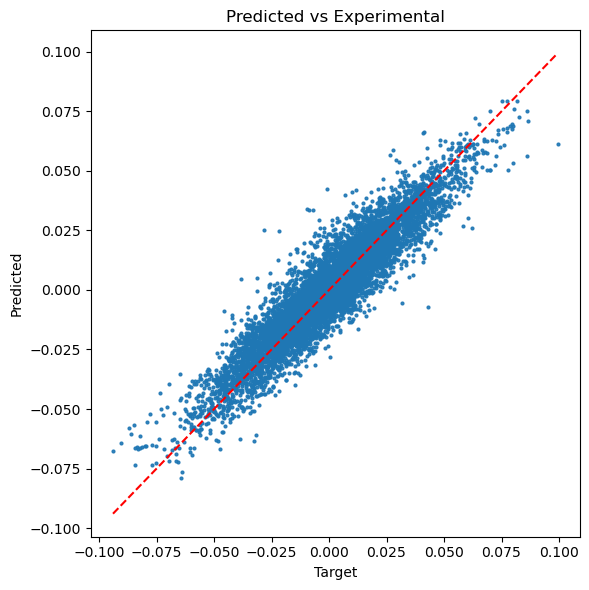

In [87]:
target = y_test
predicted = y_pred_test

plt.figure(figsize=(6, 6))
plt.scatter(target, predicted, s=4, alpha=0.9)

# Perfect prediction line
min_val = min(target.min(), predicted.min())
max_val = max(target.max(), predicted.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--')

plt.xlabel("Target")
plt.ylabel("Predicted")
plt.title("Predicted vs Experimental")
plt.tight_layout()
plt.show()